# AA_Cam_pose_sweeps

Sweeps camera density (target frame count, `cam_poses`) at a fixed video range (`start_3D_recon`..`end_3D_recon`) through every reconstruction technique, scores each against GPS ground truth, and pools everything into one CSV.

Process code (scoring, resumability/status tracking, disk-retention cleanup, the sweep loop itself) lives in `AA_cam_pose_sweeps.py`, next to this notebook -- import it, don't copy it, so fixes/improvements there apply to every per-case copy of this notebook automatically. This notebook only holds what varies per case:
- **Config**: `case_name`, frame range, `CAM_POSES`, `TECHNIQUE_ORDER`, `FLAGS`, and `DATA_STORAGE` (what to keep on disk afterwards vs delete).
- **Part 2 (Sweep)** is expensive (minutes per technique per density) and resumable -- safe to interrupt/kill and re-run from the top. GPU OOM kills the whole kernel outright (not a catchable Python exception), so the resumability design is disk-based, not in-process -- see `AA_cam_pose_sweeps.py`'s Resumability infrastructure section.
- **Part 3 (Load + plot)** is cheap -- it only reads the pooled CSV off disk, so the chart can be restyled/re-run any number of times without re-touching the sweep. Stays notebook-side since it's meant to be freely tweaked per case.

`align_and_score` and the trace loaders are reused from `F_post_recon_processing.py`/`AA_cam_pose_sweeps.py`, same functions `AA_Cam_pose_estimate_batches.ipynb` uses.

In [1]:
%load_ext autoreload
%autoreload 2

## Config

In [2]:
import sys
from pathlib import Path

# Find the repo root by walking up until we hit src/A_Config.py -- see
# AA_Cam_pose_estimate_batches.ipynb for why this is more robust than Path.cwd().parent.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "Experiments" / "templates"))
print("project_root:", project_root)

from A_Config import set_case, case_dir
from Two2D.B_video_processing import video_fps
from templates.AA_cam_pose_sweeps import reset_sweep_state, run_density_sweep

case_name = "11_walk_home_1"
experiment = "Cam_pose_v04"
set_case(case_name, experiment)  # must happen before any case_dir()/A_Config getter call below

source_dir   = case_dir() / "010_source"
videos = list(source_dir.glob("*.mp4"))
video_path = videos[0]


# Fixed video range -- only the frame DENSITY within this range varies across the sweep.
# Hardcoded per AI_coppertest3_vggt.ipynb's precedent (no reusable start/end-frame config exists yet).

start_3D_recon = 9*30

interframe_interval = 50 
max_dur = interframe_interval*201+start_3D_recon
n_steps = 10
step = interframe_interval * (200 // n_steps)
print(step)
end_3D_recon_list = []
dur = interframe_interval
while start_3D_recon + dur < max_dur:
    end_3D_recon_list.append(start_3D_recon + dur)
    dur *= 2
end_3D_recon_list.append(max_dur)
print("doubler",end_3D_recon_list)

#end_3D_recon_list = range((25*interval)+ start_3D_recon, max_dur, interval * (200 // n_steps))

end_3D_recon_list = list(range(start_3D_recon + step, max_dur, step))
print(end_3D_recon_list)
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")

# Target frame counts to sweep, ascending -- ascending order matters for the
# OOM-precaution logic in run_density_sweep (more frames -> more GPU memory).
#CAM_POSES = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250,275,300]

# Fixed run order (user-specified) -- cheapest/most-reliable techniques first.
TECHNIQUE_ORDER = ["CUT3R","CUT3R_Revisit", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]

# Which techniques are actually enabled -- same defaults as AA_Cam_pose_estimate_batches.ipynb.
FLAGS = {
     "CUT3R":       False,
    "CUT3R_Revisit": False,
    "lingbot-map": False,
    "VGGT-Omega":  True,
    "MegaSaM":     False,
    "VGGT":        False,
}

# What the sweep keeps on disk afterwards vs deletes -- see AA_cam_pose_sweeps.py's
# _cleanup_technique_output for exactly what each toggle controls.
DATA_STORAGE = {
    "keep_inputs":     True,  # extracted frames per density (020_frames_for_cam_poses)
    "keep_recon_data": True,  # full heavy technique output (images/depth/point-clouds/caches)
    "keep_cam_poses":  True,   # lightweight <technique_output>/CAM_poses/poses.csv per density
    "full_pose":       True,  # rotation too, not just translation, in the retained CSV
    "render_bev":      True,   # one <technique_output>/BEV/bev.png per technique/density --
                                # every technique gets a Reconstruction (natively for VGGT-Omega,
                                # via F_transpose_to_recon_objects.py adapters for the rest), then
                                # P_projection_mapping.BEV_tile_render_PM renders from it. Cheap
                                # to keep even when keep_recon_data=False.
}
out_dir = case_dir() / "080_Experiments"
out_dir.mkdir(parents=True, exist_ok=True)

project_root: /workspace/project


/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1000
doubler [320, 370, 470, 670, 1070, 1870, 3470, 6670, 10320]
[1270, 2270, 3270, 4270, 5270, 6270, 7270, 8270, 9270, 10270]
video fps: 30.080


## Reset sweep state

Deletes **only** this sweep's own output -- everything from running this sweep, nothing more, nothing less: every `poses_*` frame/reconstruction folder under the `experiment` tag defined above, plus the status/results CSVs. Nothing from `AA_Cam_pose_estimate_batches.ipynb` (different experiment name) or anything else in the case directory is touched.

Safe by default: with `CONFIRM_DELETE = False` this only prints what it *would* delete. Flip it to `True` and re-run the cell to actually delete.

In [3]:
CONFIRM_DELETE = True  # flip to True and re-run this cell to actually delete

reset_sweep_state(case_name, experiment, confirm=CONFIRM_DELETE)

deleted /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v04


deleted /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/Cam_pose_v04
deleted /workspace/project/Data/11_walk_home_1/080_Experiments/Cam_pose_v04
Sweep state reset.


## Ground truth

Same manual GT loading as `AA_Cam_pose_estimate_batches.ipynb` -- see that notebook for the naming-convention caveat.

In [4]:
from Q_GPS_processing import csv_to_GPS_dict

gt_csv_path = case_dir() / "000_GPS_Data" / "GPS_tags.csv"
GPS_dict = csv_to_GPS_dict(gt_csv_path)
print(f"{len(GPS_dict)} GT anchors loaded from {gt_csv_path.name}")

101 GT anchors loaded from GPS_tags.csv


## Part 2 -- Sweep (expensive, resumable, run once/rarely)

`run_density_sweep` (in `AA_cam_pose_sweeps.py`) gives each `cam_poses` value its own frames/output folders via a nested experiment tag (`f"{experiment}/poses_{cam_poses:04d}"` passed to `set_case`) -- this makes every `A_Config` getter (including `run_lingbot_map`'s, which has no path parameters at all and only reads the zero-arg getters) automatically density-scoped, with no per-function path-wrangling needed.

Safe to interrupt/kill and re-run from the top at any point.

In [ ]:
from AA_cam_pose_sweeps import run_distance_sweep
run_distance_sweep(
    case_name, experiment, video_path, start_3D_recon, end_3D_recon_list,interframe_interval,
     TECHNIQUE_ORDER, FLAGS, DATA_STORAGE, project_root, GPS_dict,
)

Video   : VID_20260810_091715159.mp4
          30.1 fps · 23254 frames · 773.6s
Range   : frames 270-1270 (1000 frames)
Sampling: every 50 frames (1.662222222222222s) → 20 candidates
Window  : ±25 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 1000/1000 [00:04<00:00, 246.78fr/s]


Selected: 20 frames  (17 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 1000/1000 [00:01<00:00, 558.33fr/s]


Log     : /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v04/poses_1270/selection_log.json
Sharpness (at 25% res): min 2032 · mean 4021 · max 5679
20 frames  →  /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/Cam_pose_v04/poses_1270
GPU freed -- 0.01 GiB still allocated, 0.02 GiB reserved
Saved: /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/Cam_pose_v04/poses_1270/predictions.npz
Saved: /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/Cam_pose_v04/poses_1270/scene.glb
min depth tensor(0.0297, device='cuda:0')
torch.Size([5283839, 3])
mins, maxes and ranges -1.8739091396331786 5.299042844772339 7.172951984405518 -0.15623046271502972 5.25601371191442 5.41224417462945
scale - original 368.9241924938728
min depth tensor(0.0297, device='cuda:0')
torch.Size([5019647, 3])
mins, maxes and ranges -1.4941966533660889 2.141490936279297 3.6356875896453857 -0.02524312846362592 2.5052796926349403 2.5305228210985664
scale - original 738.6491127728

...

Log     : /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v04/poses_3270/selection_log.json
Sharpness (at 25% res): min 896 · mean 4229 · max 8757
60 frames  →  /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/Cam_pose_v04/poses_3270
GPU freed -- 0.01 GiB still allocated, 0.02 GiB reserved
Saved: /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/Cam_pose_v04/poses_3270/predictions.npz
Saved: /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/Cam_pose_v04/poses_3270/scene.glb
min depth tensor(0.0138, device='cuda:0')
torch.Size([15851519, 3])
mins, maxes and ranges -0.962957364320755 5.784434181451798 6.747391545772553 -1.1478502362966538 5.150937816500663 6.298788052797317
scale - original 610.7155652146214
min depth tensor(0.0138, device='cuda:0')
torch.Size([15058943, 3])
mins, maxes and ranges -0.748108521103859 2.5161596089601517 3.2642681300640106 -0.07264823410660029 2.2967411311343313 2.3693893652409317
scale - original 1395.35950424

Pass 1: scoring: 100%|██████████| 4000/4000 [00:14<00:00, 273.18fr/s]


Selected: 80 frames  (59 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 4000/4000 [00:07<00:00, 559.72fr/s]


Log     : /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v04/poses_4270/selection_log.json
Sharpness (at 25% res): min 896 · mean 4225 · max 8963
80 frames  →  /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/Cam_pose_v04/poses_4270


## Part 3 -- Load + plot (cheap, re-runnable independently)

Reads `density_sweep_results.csv` fresh from disk -- does not depend on Part 2 having just run, so this cell can be re-run/restyled any number of times without touching the sweep. Colour mapping matches the informal `tab10`-by-insertion-order precedent in `AA_CAM_POSE_COMPARE_01.ipynb` cell 25 (`lingbot_map`, `VGGT_O`, `CUT3R`, `MegaSaM` kept at their original slots; `VGGT` plain wasn't in that precedent, so it reuses the freed `Reality_Scan` slot).

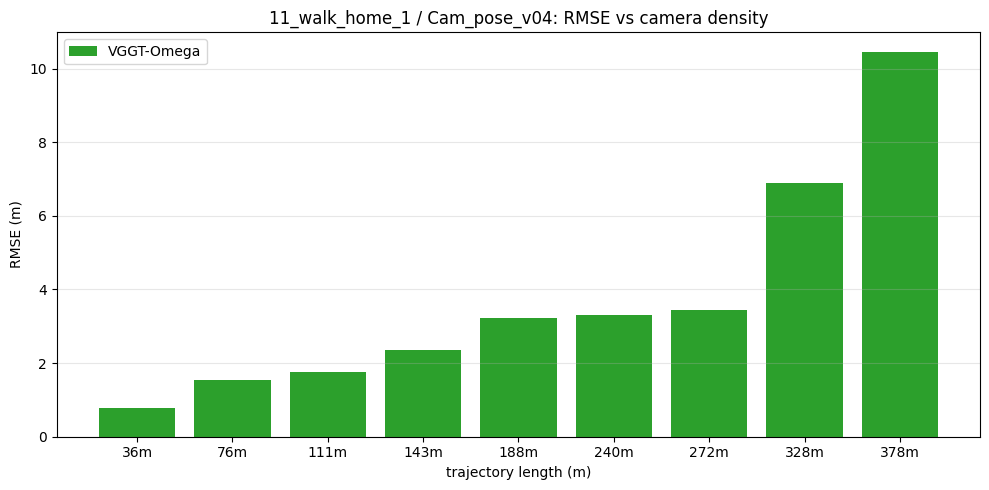

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir


results_path = case_dir() / "080_Experiments" / f"{experiment}" /f"{experiment}_results.csv"

TECHNIQUE_ORDER = ["CUT3R", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],  # no precedent either -- n
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["cam_poses"].unique())
traj_len_labels = [f"{df.loc[df['cam_poses']==cp, 'trajectory length (m)'].iloc[0]:.0f}m" for cp in cam_poses_vals]

x = np.arange(len(cam_poses_vals))
width = 0.8 / max(len(techniques), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax.set_xticks(x)
ax.set_xticklabels(traj_len_labels)
ax.set_xlabel("trajectory length (m)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / f"{case_name}_{experiment}_RMSE.svg", format="svg", bbox_inches="tight")

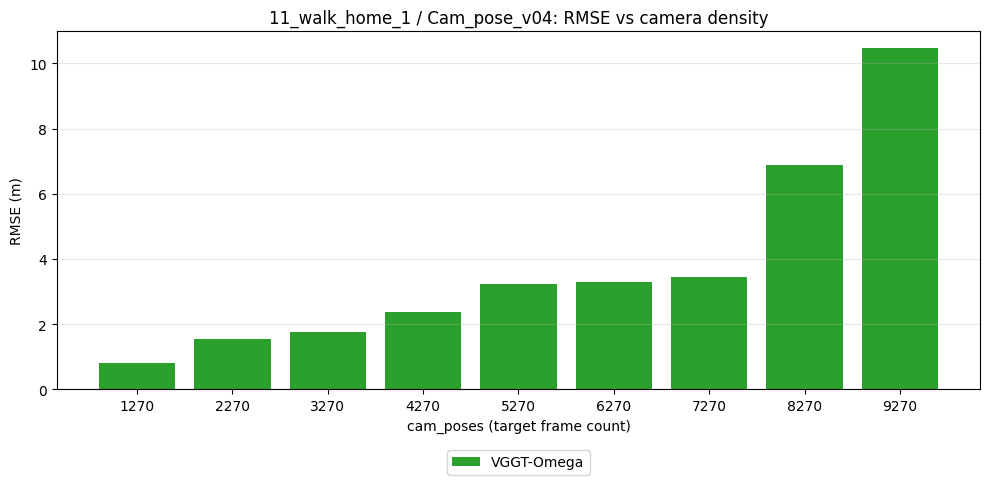

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir



set_case(case_name, experiment)
results_path = case_dir() / "080_Experiments" / f"{experiment}" / f"{experiment}_results.csv"

TECHNIQUE_ORDER = ["CUT3R", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["cam_poses"].unique())

x = np.arange(len(cam_poses_vals))
width = 0.8 / max(len(techniques), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax.set_xticks(x)
ax.set_xticklabels(cam_poses_vals)
ax.set_xlabel("cam_poses (target frame count)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / f"{case_name}_{experiment}_RMSE_nocut3rr.svg", format="svg", bbox_inches="tight")

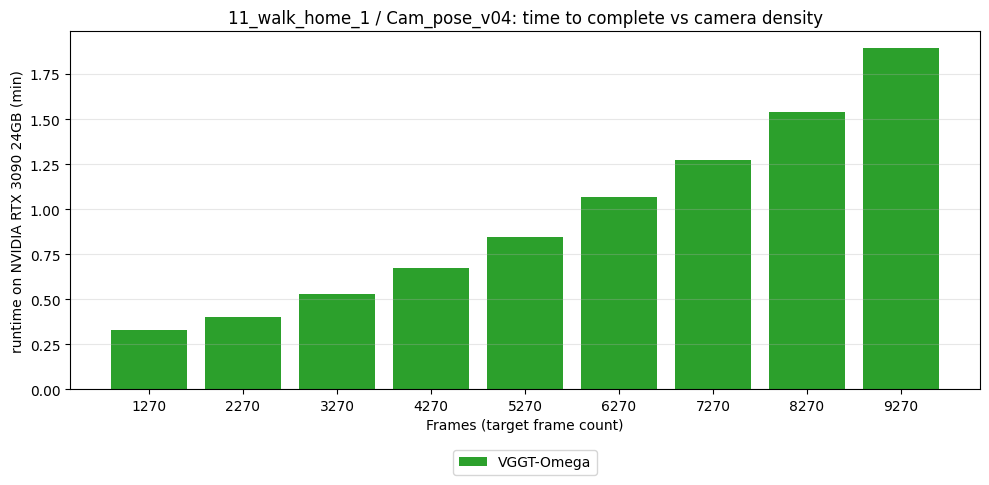

In [ ]:
fig3, ax3 = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["runtime (min)"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax3.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax3.set_xticks(x)
ax3.set_xticklabels(cam_poses_vals)
ax3.set_xlabel("Frames (target frame count)")
ax3.set_ylabel("runtime on NVIDIA RTX 3090 24GB (min)")
ax3.set_title(f"{case_name} / {experiment}: time to complete vs camera density")
ax3.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))
ax3.grid(axis="y", alpha=0.3)
fig3.tight_layout()
fig3.savefig(out_dir / f"{case_name}_{experiment}_runtime.svg", format="svg", bbox_inches="tight")

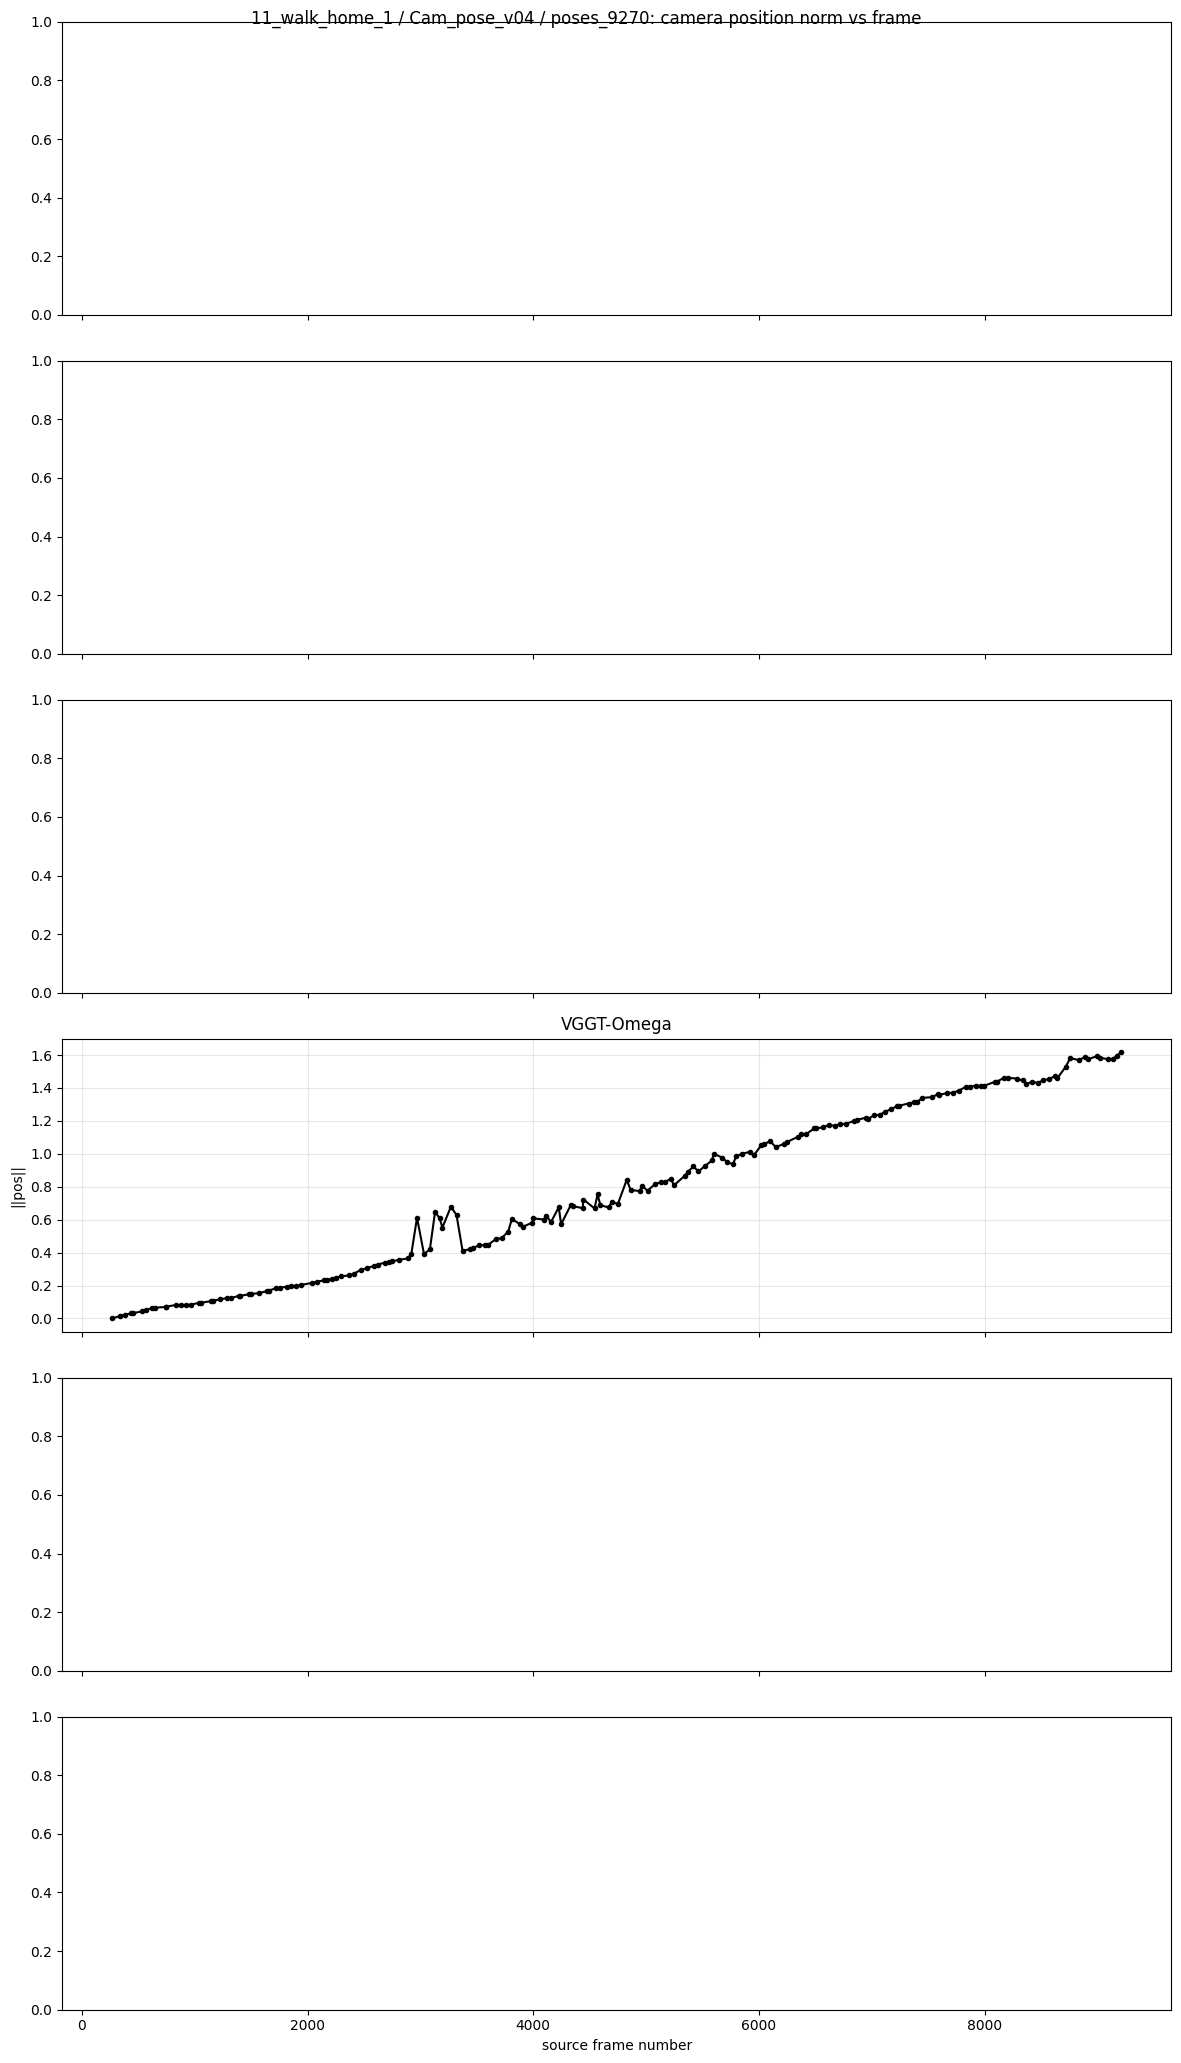

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from A_Config import (
    cut3r_output_dir, lingbot_map_dir, vggt_o_output_dir, case_dir, case_name as _case_name,
)

# Every technique's poses.csv lives at <technique_output_dir>/CAM_poses/poses.csv --
# map technique name -> its output dir accessor so this cell works for whichever
# techniques were actually run for the current set_case(...) density/end-frame folder.
subfolder = "poses_9270"
TECHNIQUE_DIRS = {
    "CUT3R":          cut3r_output_dir()/subfolder,
    "CUT3R_Revisit":  cut3r_output_dir() / "revisit"/subfolder,
    "lingbot-map":    lingbot_map_dir()/subfolder,
    "VGGT-Omega":     vggt_o_output_dir()/subfolder,
    "MegaSaM":        case_dir() / "036_MEGASAM_output" / experiment/subfolder,
    "VGGT":           case_dir() / "034_VGGT_output" / experiment/subfolder,
}

fig, axes = plt.subplots(len(TECHNIQUE_DIRS), 1, figsize=(12, 3.5*len(TECHNIQUE_DIRS)), sharex=True)

for ax, (method, out_dir_trace) in zip(axes, TECHNIQUE_DIRS.items()):
    csv_path = out_dir_trace / "CAM_poses" / "poses.csv"
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path).sort_values("frame")
    norms = np.linalg.norm(df[["x", "y", "z"]].to_numpy(), axis=1)
    ax.plot(df["frame"], norms, "o-", color="k", markersize=3)

    ax.set_ylabel("||pos||")
    ax.set_title(method)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("source frame number")
fig.suptitle(f"{case_name} / {experiment} / {subfolder}: camera position norm vs frame")
fig.tight_layout()




/tmp/ipykernel_114433/3957424697.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


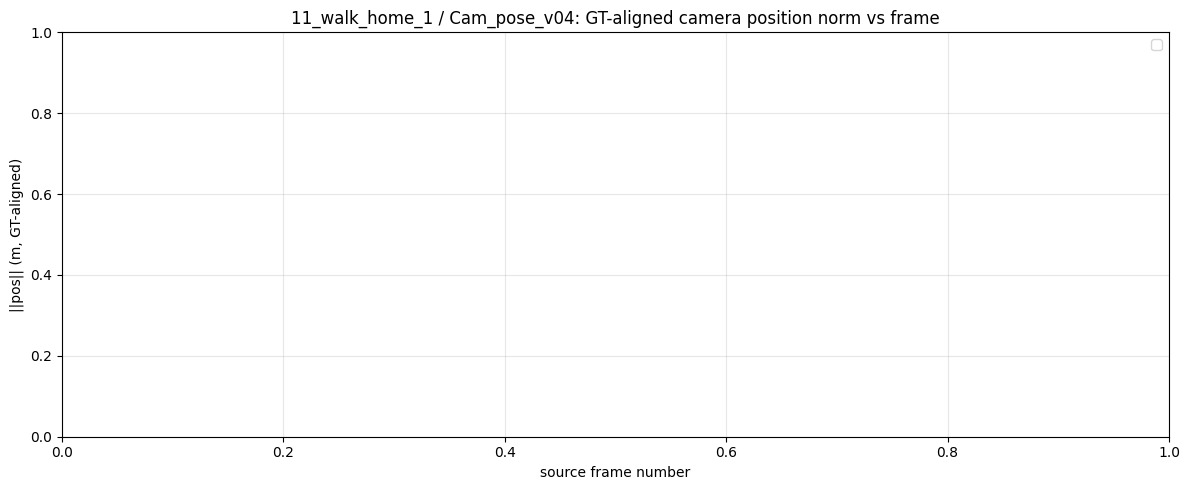

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from A_Config import cut3r_output_dir, lingbot_map_dir, vggt_o_output_dir, case_dir
from Q_Metric_georeferencing import GPS_camerapose_matcher
from Thr3D.G_transforms_alignments import umeyama_align
subfolder = "poses_14270"
TECHNIQUE_DIRS = {
    "CUT3R":          cut3r_output_dir()/subfolder,
    "CUT3R_Revisit":  cut3r_output_dir() / "revisit"/subfolder,
    "lingbot-map":    lingbot_map_dir()/subfolder,
    "VGGT-Omega":     vggt_o_output_dir()/subfolder,
    "MegaSaM":        case_dir() / "036_MEGASAM_output" / experiment/subfolder,
    "VGGT":           case_dir() / "034_VGGT_output" / experiment/subfolder,
}

fig, ax = plt.subplots(figsize=(12, 5))
for technique, out_dir in TECHNIQUE_DIRS.items():
    csv_path = out_dir / "CAM_poses" / "poses.csv"
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path).sort_values("frame")
    cam_pose_dict = {int(r.frame): np.array([r.x, r.y, r.z]) for r in df.itertuples()}

    # Same correspondences + same R/s/t as align_and_score -- fit only on the
    # matched GPS anchors, then applied to every frame so the whole trace
    # (not just the matched subset) lands in metres.
    GPS_locs, lat_0, lon_0, object_locs = GPS_camerapose_matcher(GPS_dict, cam_pose_dict)
    R, s, t, _, rmse = umeyama_align(GPS_locs, object_locs, label_A="GT", label_B=technique, out_path=None)

    all_pos = df[["x", "y", "z"]].to_numpy()
    aligned = (s * R @ all_pos.T).T + t
    norms = np.linalg.norm(aligned, axis=1)
    ax.plot(df["frame"], norms, "o-", label=f"{technique} (rmse={rmse:.2f}m)", markersize=3)

ax.set_xlabel("source frame number")
ax.set_ylabel("||pos|| (m, GT-aligned)")
ax.set_title(f"{case_name} / {experiment}: GT-aligned camera position norm vs frame")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
